# Correlations Go to One — a quantitative teardown 🔬
### Conditional correlation · the BGL/Forbes–Rigobon artefact · a constant-correlation GARCH null · exceedances · the holder's arithmetic

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

**Beat 0 · Verdict (real tape).** Past-only crisis regime: average pairwise correlation
0.206 → 0.466; constant-correlation GARCH artefact
-0.001; genuine **+0.262**, circular block-bootstrap 95% CI
[+0.147, +0.345] (bootstrap *t* ≈ 5.0). FR-adjusted
crisis correlation 0.160 < calm: interdependence, not contagion. Equal-weight book:
crisis vol 37.1% vs 26.0% predicted → correlation shortfall
**+42.9%** [+26.0%, +54.3%], DR 2.14 →
1.44. Headline numbers: [`docs/results.md`](../docs/results.md) (as-of
2022-11-30, fingerprints `bbc82157e299` / `e223c581ae22`; 40 sims, 400 bootstrap
replicates). Cells below re-run on the same tape with fewer replications.

> ⚠️ **Not investment advice.** Survivor sample of 20 large caps (skfolio `sp500_dataset`); the
> S&P 500 series is a **price** index used only as the state variable.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.
> The plain-language story is in [01_for_the_curious.ipynb](01_for_the_curious.ipynb).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from goestoone import data, strategy as st
R, m = data.load_returns()
print(f"as-of {data.AS_OF} | {R.shape[1]} stocks (survivor sample), {len(R)} days, "
      f"{R.index[0].date()} -> {R.index[-1].date()}")
print(f"fingerprints: stocks {data.fingerprint(data.load_prices())}, "
      f"index {data.fingerprint(data.load_index())}")

as-of 2022-11-30 | 20 stocks (survivor sample), 8293 days, 1990-01-03 -> 2022-11-30
fingerprints: stocks bbc82157e299, index e223c581ae22


## 1 · The claim, steelmanned

"Correlations go to one in a crisis" (Page & Panariello 2018 for a practitioner statement;
Longin & Solnik 2001 and Ang & Chen 2002 for the academic evidence of tail and downside
dependence). Hypotheses, fixed before the run:

- **H₁ (naive).** Average pairwise correlation is higher in crisis than calm regimes.
- **H₂ (genuine).** The gap survives subtracting what the identical procedure reports under a
  constant-correlation model with the tape's own volatility dynamics. *Signal stamp hinges on
  this:* Real iff the headline (past-21-day vol) genuine gap has a block-bootstrap 95% CI above
  zero and is positive in ≥ half of six regime definitions.
- **H₃ (mechanism).** Forbes–Rigobon: is the rise explained by a louder common factor at constant
  betas?
- **H₄ (tails).** Exceedance correlations exceed the Gaussian benchmark, more on the downside.
- **H₅ (holder).** An equal-weight book's crisis vol exceeds the vol implied by calm correlations
  and crisis volatilities. *Tradability:* Fragile iff that shortfall is ≥ 5% with CI above 0;
  otherwise Mirage. Investable is unreachable — nothing here is a trading rule.

## 2 · Why the naive number is biased — Boyer, Gibson & Loretan in one line

For ``y = βx + ε`` with the subsample selected on ``x`` alone and ``k = Var(x|A)/Var(x)``:
``ρ_A = ρ√k / √(1 + ρ²(k−1))``. The Forbes–Rigobon adjustment is its exact inverse.

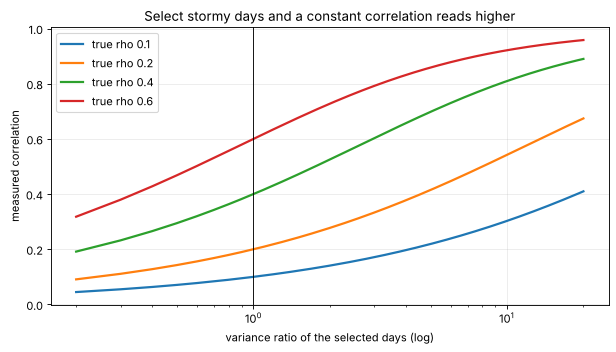

selected |x|>1.5: measured 0.529, closed form 0.528, truth 0.300


In [2]:
k = np.linspace(0.2, 20, 200)
fig, ax = plt.subplots(figsize=(9, 4.5))
for rho in (0.1, 0.2, 0.4, 0.6):
    ax.plot(k, [st.bgl_conditional_corr(rho, kk) for kk in k], lw=2, label=f"true rho {rho}")
ax.axvline(1, color="k", lw=0.8)
ax.set_xscale("log"); ax.set_xlabel("variance ratio of the selected days (log)")
ax.set_ylabel("measured correlation"); ax.legend()
ax.set_title("Select stormy days and a constant correlation reads higher")
plt.show()
# Monte-Carlo check of the closed form
rng = np.random.default_rng(1018)
x = rng.normal(size=400_000); y = 0.3 * x + np.sqrt(1 - 0.09) * rng.normal(size=400_000)
sel = np.abs(x) > 1.5
print(f"selected |x|>1.5: measured {np.corrcoef(x[sel], y[sel])[0, 1]:.3f}, closed form "
      f"{st.bgl_conditional_corr(0.3, x[sel].var() / x.var()):.3f}, truth 0.300")

> 💡 **In plain words.** The S&P's variance on high-vol days is ~11× its calm level. At
> that ratio a true correlation of 0.2 would *read* about 0.55 if you selected on the market's
> own moves. That is why the folklore number cannot be taken at face value.

## 3 · The teardown

### 3.1 Naive gaps under six definitions

In [3]:
labels = st.all_labels(m)
naive = pd.DataFrame({k: st.regime_corr(R, lab) for k, lab in labels.items()}).T
naive["past_only"] = [st.REGIMES[k]["past_only"] for k in naive.index]
naive

,calm,crisis,diff,n_calm,n_crisis,past_only
past21,0.206,0.466,0.260,"4,136.000",828.000,True
past63,0.213,0.458,0.245,"4,115.000",823.000,True
garch,0.196,0.474,0.278,"4,147.000",830.000,True
drawdown,0.208,0.436,0.228,"4,152.000","1,824.000",True
month_vol,0.171,0.491,0.320,"4,159.000",834.000,False
big_down,0.045,0.247,0.202,"4,147.000",415.000,False


### 3.2 The exact simulation benchmark — constant-correlation GARCH

Each stock and the S&P: GARCH(1,1) on the real tape; shocks Gaussian with the **constant**
correlation of the standardised residuals (Bollerslev 1990). The identical regime procedure on
simulated paths gives the artefact; the circular block bootstrap (63-day blocks, labels carried
with days) gives the interval for ``naive − artefact``.

median alpha+beta 0.993; constant shock correlation (stocks) 0.281


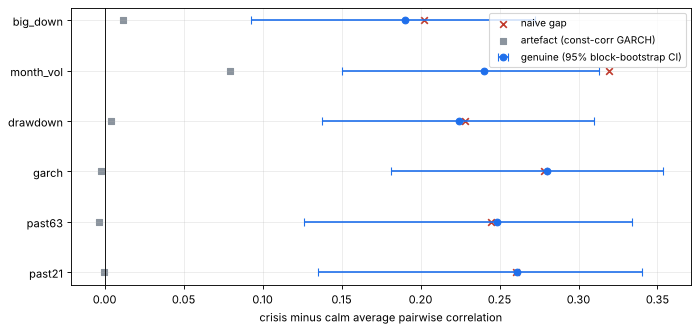

,naive,artefact,genuine,ci_lo,ci_hi,p
regime,,,,,,
past21,0.260,-0.000,0.261,0.135,0.340,0.008
past63,0.245,-0.004,0.248,0.126,0.334,0.008
garch,0.278,-0.002,0.280,0.181,0.353,0.008
drawdown,0.228,0.004,0.224,0.137,0.310,0.008
month_vol,0.320,0.079,0.240,0.150,0.313,0.008
big_down,0.202,0.012,0.190,0.092,0.272,0.008


In [4]:
fit = st.fit_ccc_garch(R, m)
print(f"median alpha+beta {np.median([p['alpha'] + p['beta'] for p in fit['params']]):.3f}; "
      f"constant shock correlation (stocks) {fit['avg_corr_stocks']:.3f}")
art = st.artefact_benchmark(fit, n_sims=10, seed=1018, exceed=True)
Z = st.devolatilise(R, m, fit)
bt = st.bootstrap(R, m, labels, n_boot=120, block=63, seed=1018, exceed=True, Z=Z)
rows = []
for k in labels:
    a = art["regimes"][k]["diff_mean"]
    lo, hi = st.ci(bt[k]["diff"], centre_shift=a)
    rows.append({"regime": k, "naive": naive.loc[k, "diff"], "artefact": a,
                 "genuine": naive.loc[k, "diff"] - a, "ci_lo": lo, "ci_hi": hi,
                 "p": st.boot_p_positive(bt[k]["diff"], centre_shift=a)})
dec = pd.DataFrame(rows).set_index("regime")
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(dec))
ax.errorbar(dec["genuine"], y, xerr=[dec["genuine"] - dec["ci_lo"], dec["ci_hi"] - dec["genuine"]],
            fmt="o", color="#1f6feb", capsize=4, label="genuine (95% block-bootstrap CI)")
ax.scatter(dec["naive"], y, marker="x", color="#c0392b", label="naive gap")
ax.scatter(dec["artefact"], y, marker="s", color="#8b949e", label="artefact (const-corr GARCH)")
ax.axvline(0, color="k", lw=0.8); ax.set_yticks(y); ax.set_yticklabels(dec.index)
ax.set_xlabel("crisis minus calm average pairwise correlation"); ax.legend(fontsize=9)
plt.show()
dec

> 💡 **In plain words.** Under a model whose conditional correlation never moves, a
> *past-only* regime reports ≈ 0 — the artefact needs the selection to see the day's own
> realisations. The contemporaneous month-volatility definition does see them, and manufactures
> roughly a quarter of its own gap. Every definition still leaves a large, significant genuine
> rise.

### 3.3 Forbes–Rigobon and the constant-beta benchmark

In [5]:
rows = []
for k, lab in labels.items():
    fr = st.fr_panel(R, m, lab); cb = st.constant_beta_benchmark(R, m, lab)
    iv = st.idio_vol_ratio(R, m, lab)
    rows.append({"regime": k, "calm": fr["calm_raw"], "crisis": fr["crisis_raw"],
                 "crisis_FR_adj": fr["crisis_fr"], "const_beta_implies": cb["implied_crisis"],
                 "mkt_var_x": fr["var_ratio"], "idio_vol_x": iv["idio_vol_ratio"],
                 "beta_x": iv["beta_ratio"]})
frt = pd.DataFrame(rows).set_index("regime")
frt

,calm,crisis,crisis_FR_adj,const_beta_implies,mkt_var_x,idio_vol_x,beta_x
regime,,,,,,,
past21,0.206,0.466,0.160,0.698,11.200,1.561,0.997
past63,0.213,0.458,0.164,0.697,10.266,1.594,0.986
garch,0.196,0.474,0.153,0.715,12.937,1.594,0.988
drawdown,0.208,0.436,0.229,0.487,4.386,1.027,0.998
month_vol,0.171,0.491,0.140,0.733,16.933,1.572,0.973
big_down,0.045,0.247,0.058,0.399,21.244,1.351,0.999


> 💡 **In plain words.** Betas didn't change (×1.00). The market got ~3.3× more volatile;
> stock-specific risk only ~1.6×. Correlation is the common part's share of the total, so it rose.
> Forbes and Rigobon call that "interdependence, not contagion" and their adjustment pulls the
> crisis correlation *below* the calm one. Both statements are true at once: the transmission is
> unchanged, *and* the holder's diversification got worse. The constant-beta benchmark
> over-predicts (≈0.70) precisely because idiosyncratic risk rose too.

### 3.4 Exceedance correlations

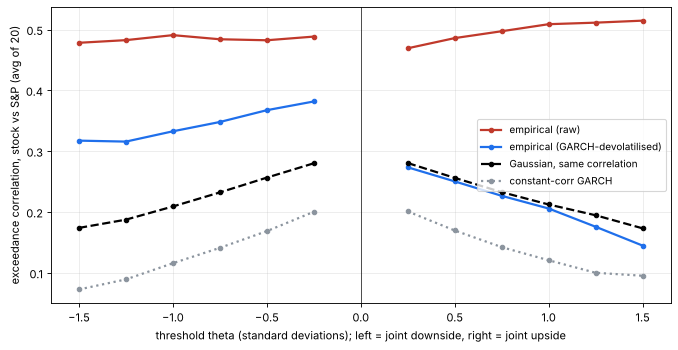

asymmetry (down - up): raw -0.019 CI (-0.07730510402678778, 0.06708807592988555), devolatilised +0.139 CI (0.07029697449672614, 0.2087146079861946), const-corr GARCH -0.009
Ang-Chen H vs Gaussian: down 0.264, up 0.278


In [6]:
cur = st.exceedance_panel(R, m)
gau = st.gaussian_panel_curve(R, m)
curz = st.exceedance_panel(*Z)
fig, ax = plt.subplots(figsize=(10, 4.8))
for s, lab, c, ls in ((cur, "empirical (raw)", "#c0392b", "-"),
                      (curz, "empirical (GARCH-devolatilised)", "#1f6feb", "-"),
                      (gau, "Gaussian, same correlation", "k", "--"),
                      (art["curve"], "constant-corr GARCH", "#8b949e", ":")):
    for side in (s[s.index < 0], s[s.index > 0]):
        ax.plot(side.index, side.values, ls, color=c, lw=2, marker="o", ms=4,
                label=lab if side.index[0] < 0 else None)
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("threshold theta (standard deviations); left = joint downside, right = joint upside")
ax.set_ylabel("exceedance correlation, stock vs S&P (avg of 20)"); ax.legend(fontsize=9)
plt.show()
print(f"asymmetry (down - up): raw {st.asymmetry(cur):+.3f} CI {st.ci(bt['_asym'])}, "
      f"devolatilised {st.asymmetry(curz):+.3f} CI {st.ci(bt['_asym_devol'])}, "
      f"const-corr GARCH {art['asym_mean']:+.3f}")
print(f"Ang-Chen H vs Gaussian: down {st.ang_chen_h(cur, gau, 'down'):.3f}, "
      f"up {st.ang_chen_h(cur, gau, 'up'):.3f}")

> 💡 **In plain words.** A normal distribution says correlation should *fade* in the
> tails (dashed line). Real stock-index tails stay at ~0.5 on both sides — far more joint
> extremes than a normal model allows. On raw daily returns the two sides are about equal,
> because the biggest rebounds happen inside the same volatile clusters as the biggest drops.
> Measured relative to the volatility of the moment, the downside shocks are clearly the more
> correlated ones — the Longin–Solnik / Ang–Chen asymmetry survives, in that form.

### 3.5 The holder

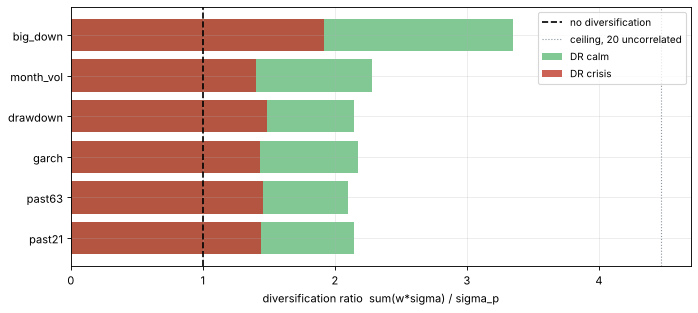

,vol_calm,vol_crisis,vol_pred,shortfall,artefact,genuine,ci_lo,ci_hi,dr_calm,dr_crisis
regime,,,,,,,,,,
past21,0.124,0.371,0.260,0.428,0.003,0.425,0.251,0.537,2.142,1.440
past63,0.124,0.358,0.258,0.390,-0.004,0.393,0.220,0.510,2.100,1.454
garch,0.121,0.384,0.263,0.462,-0.002,0.464,0.319,0.573,2.174,1.430
drawdown,0.140,0.260,0.187,0.388,0.005,0.383,0.254,0.495,2.141,1.483
month_vol,0.114,0.396,0.253,0.564,0.139,0.425,0.286,0.534,2.282,1.405
big_down,0.077,0.215,0.123,0.752,0.039,0.713,0.373,0.949,3.347,1.916


In [7]:
rows = []
for k, lab in labels.items():
    ps = st.portfolio_stats(R, lab)
    a = art["regimes"][k]["shortfall_mean"]
    lo, hi = st.ci(bt[k]["shortfall"], centre_shift=a)
    rows.append({"regime": k, "vol_calm": ps["vol_calm"], "vol_crisis": ps["vol_crisis"],
                 "vol_pred": ps["vol_pred"], "shortfall": ps["shortfall"], "artefact": a,
                 "genuine": ps["shortfall"] - a, "ci_lo": lo, "ci_hi": hi,
                 "dr_calm": ps["dr_calm"], "dr_crisis": ps["dr_crisis"]})
port = pd.DataFrame(rows).set_index("regime")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(port.index, port["dr_calm"], color="#2ea44f", alpha=0.6, label="DR calm")
ax.barh(port.index, port["dr_crisis"], color="#c0392b", alpha=0.8, label="DR crisis")
ax.axvline(1, color="k", lw=1.5, ls="--", label="no diversification")
ax.axvline(np.sqrt(20), color="#8b949e", lw=1, ls=":", label="ceiling, 20 uncorrelated")
ax.set_xlabel("diversification ratio  sum(w*sigma) / sigma_p"); ax.legend(fontsize=9)
plt.show()
port

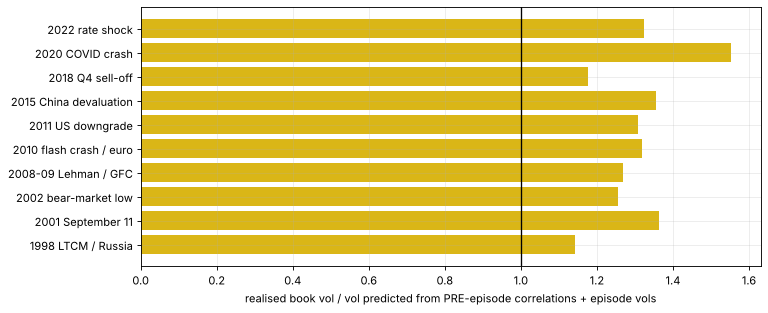

,start,end,days,corr_before,corr_during,vol_during,vol_pred,ratio,dr_before,dr_during
episode,,,,,,,,,,
1998 LTCM / Russia,1998-08-01,1998-10-15,53,0.319,0.413,0.376,0.329,1.142,1.794,1.530
2001 September 11,2001-09-17,2001-10-31,33,0.122,0.258,0.248,0.182,1.364,2.358,1.707
2002 bear-market low,2002-07-01,2002-10-31,87,0.236,0.446,0.360,0.287,1.255,1.861,1.487
2008-09 Lehman / GFC,2008-09-15,2009-03-31,137,0.342,0.604,0.593,0.467,1.269,1.657,1.287
2010 flash crash / euro,2010-05-01,2010-07-31,63,0.327,0.604,0.237,0.180,1.318,1.664,1.251
2011 US downgrade,2011-08-01,2011-10-31,65,0.369,0.693,0.342,0.261,1.307,1.593,1.201
2015 China devaluation,2015-08-17,2015-09-30,32,0.341,0.664,0.283,0.209,1.354,1.731,1.252
2018 Q4 sell-off,2018-10-01,2018-12-31,63,0.308,0.456,0.227,0.193,1.176,1.767,1.499
2020 COVID crash,2020-02-20,2020-04-30,50,0.246,0.701,0.701,0.451,1.553,1.888,1.195


In [8]:
ep = st.episode_table(R)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(ep.index, ep["ratio"], color="#dab617")
ax.axvline(1, color="k", lw=1.2)
ax.set_xlabel("realised book vol / vol predicted from PRE-episode correlations + episode vols")
plt.show()
ep.round(3)

> 💡 **In plain words.** With the yardstick a holder actually had — last year's
> correlations — every episode was riskier than "same correlations, higher volatility" (ratios
> 1.14–1.55). The diversification ratio never touched 1.

### 3.6 Synthetic control — the machinery, not the market

In [9]:
rows = []
for s in (0.0, 0.5, 1.0):
    Rs, ms, tr = data.synthetic_panel(n_assets=10, n_years=16, signal_strength=s, seed=1018)
    d = st.crisis_correlation_test(Rs, ms, n_sims=6, n_boot=100)
    mv = st.regime_corr(Rs, st.regime_labels(ms, "month_vol"))["diff"]
    rows.append({"strength": s, "planted": tr["planted_jump"], "naive": d["diff"],
                 "artefact": d["artefact"], "genuine": d["genuine"], "ci_lo": d["ci_lo"],
                 "ci_hi": d["ci_hi"], "fires": d["significant"], "month_vol_naive": mv})
pd.DataFrame(rows).set_index("strength")

,planted,naive,artefact,genuine,ci_lo,ci_hi,fires,month_vol_naive
strength,,,,,,,,
0.000,0.000,0.015,-0.016,0.031,-0.044,0.092,False,0.108
0.500,0.150,0.126,-0.014,0.141,0.063,0.209,True,0.213
1.000,0.300,0.238,-0.015,0.253,0.168,0.331,True,0.332


> 💡 **In plain words.** Constant correlation (strength 0): the detector is quiet, but the
> contemporaneous month-vol measurement still shows a positive gap — the artefact, alone. Planted
> jump: the detector fires. A synthetic result proves the harness, never the market.

## 4 · The verdict

**Signal: Real.** Genuine past-only rise +0.262, CI
[+0.147, +0.345], positive in 6/6 definitions; the
artefact is ≈ 0 for past-only regimes and +0.078 of +0.320
for the contemporaneous month-vol one. FR-adjusted crisis correlation 0.160:
interdependence, not contagion. Max 63-day average correlation 0.73 — never one.
Raw exceedance asymmetry -0.019 [-0.074, +0.067]; devolatilised
+0.139 [+0.073, +0.204].

**Tradability: Fragile.** Correlation shortfall +42.9%
[+26.0%, +54.3%]; DR 2.14 → 1.44;
episodes median 1.31×. Real for risk budgets, not a return stream.

## 5 · Could you trade it?

There is no position here. The usable output is a **risk-model correction**: scale crisis
covariances by both a volatility multiplier *and* a correlation stress (here, roughly +0.25 on
average pairwise correlation, or ×1.4 on equal-weight book vol beyond the volatility effect). A
past-only regime identifies the state with essentially no artefact, so the correction can be
applied in real time — but volatility forecasting already captures most of the timing, and the
residual is a capital-allocation input, not alpha.

## 6 · Going further

- **DCC** (Engle 2002) instead of regimes: a continuous conditional-correlation path, and a test of
  whether its crisis level beats the CCC null on the same tape.
- **Fat-tailed null**: Student-*t* shocks in the CCC benchmark widen the contemporaneous artefact;
  the past-only conclusion should not move.
- **Cross-asset** (stock–bond) correlations, where the sign itself changes by regime.
- **Survivorship**: a point-in-time constituent panel would test the reasoned direction of the bias.
- Neighbours on the desk: 578 (correlation regime as a *return predictor*), 1010 (estimation noise
  in correlation matrices), 502 (correlation as a cross-sectional sort), 974 (diversification
  saturation).